# Project 3 — Connect-4 Policy Gradient Training

This notebook implements **Questions 1–3** of the assignment:
1. Select a pretrained Connect-4 network as **M1** (Stiles Transformer).
2. Improve M1 via **policy gradient self-play** against randomly chosen M2 opponents.
3. Maintain a growing **opponent pool** that periodically absorbs frozen copies of the updated M1.

Heavy logic lives in `src/`; this notebook stays thin — it just wires things together and shows results.

In [6]:
# ── Cell 1: Imports and path setup ───────────────────────────────────────────
import sys
import os
import random

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Add the project root to sys.path so 'src' is importable as a package
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src import config, game_engine, model_loader, opponent_pool, pg_trainer

print(f"TensorFlow version : {tf.__version__}")
print(f"Project root       : {PROJECT_ROOT}")

TensorFlow version : 2.20.0
Project root       : c:\Users\stile\Desktop\Opti Proj 3


In [7]:

wandb login

In [8]:
# ── Cell 2: Set random seeds for reproducibility ──────────────────────────────
random.seed(config.SEED)
np.random.seed(config.SEED)
tf.random.set_seed(config.SEED)

print(f"Seeds set to {config.SEED}")
print()
print("Key hyperparameters:")
print(f"  GAMES_PER_GROUP    = {config.GAMES_PER_GROUP}")
print(f"  BATCH_SIZE         = {config.BATCH_SIZE}")
print(f"  GAMMA              = {config.GAMMA}")
print(f"  LEARNING_RATE      = {config.LEARNING_RATE}")
print(f"  NUM_GROUPS         = {config.NUM_GROUPS}")
print(f"  RANDOM_INIT_MOVES  = {config.RANDOM_INIT_MOVES}")
print(f"  POOL_CAP           = {config.POOL_CAP}")
print(f"  POOL_ADD_INTERVAL  = {config.POOL_ADD_INTERVAL}")
print(f"  CHECKPOINT_INTERVAL= {config.CHECKPOINT_INTERVAL}")

Seeds set to 42

Key hyperparameters:
  GAMES_PER_GROUP    = 50
  BATCH_SIZE         = 32
  GAMMA              = 0.99
  LEARNING_RATE      = 0.0005
  NUM_GROUPS         = 500
  RANDOM_INIT_MOVES  = 6
  POOL_CAP           = 20
  POOL_ADD_INTERVAL  = 50
  CHECKPOINT_INTERVAL= 50


In [9]:
# ── Cell 3: Load all models ───────────────────────────────────────────────────
# This may take ~30–60 seconds on first run (Keras/TF model loading).
models = model_loader.load_all_models()

m1_wrapper = models["m1"]
print(f"\nM1 (to be trained): {m1_wrapper.name}  |  encoding={m1_wrapper.encoding}")

Loading Stiles models…
Loading Luke models…

Loading Zan models…

Loaded 7 models:
  m1                              encoding=B  (Stiles Transformer (M1))
  stiles_transformer_orig         encoding=B  (Stiles Transformer (original))
  stiles_cnn                      encoding=B  (Stiles CNN)
  luke_cnn                        encoding=A  (Luke CNN)
  luke_transformer                encoding=A  (Luke Transformer)
  zan_cnn                         encoding=B  (Zan CNN)
  zan_transformer                 encoding=B_flat  (Zan Transformer)

M1 (to be trained): Stiles Transformer (M1)  |  encoding=B


In [10]:
# ── Cell 4: Build the opponent pool ──────────────────────────────────────────
# All models except M1 itself seed the pool as permanent (never-removed) opponents.
initial_m2 = [wrapper for key, wrapper in models.items() if key != "m1"]
pool = opponent_pool.OpponentPool(initial_m2)

print(pool)

OpponentPool(size=6, opponents=['Stiles Transformer (original)', 'Stiles CNN', 'Luke CNN', 'Luke Transformer', 'Zan CNN', 'Zan Transformer'])


In [ ]:
# ── Cell 5: Run the policy gradient training loop ────────────────────────────
# Progress is printed every 10 groups; M1 is checkpointed every CHECKPOINT_INTERVAL.
# Checkpoints are saved to checkpoints/  and the full log to logs/training_log.json.
log = pg_trainer.train(m1_wrapper, pool)

wandb: Currently logged in as: stiles-clements1 (stiles-clements1-the-university-of-texas-at-austin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[Group    1] loss=-0.120 | win%=56% | roll(loss)=-0.120 | roll(win%)=56% | vs=Luke Transformer
[Group    2] loss=-0.081 | win%=54% | roll(loss)=-0.101 | roll(win%)=55% | vs=Zan Transformer
[Group    3] loss=-0.077 | win%=58% | roll(loss)=-0.093 | roll(win%)=56% | vs=Stiles Transformer (original)
[Group    4] loss=-0.066 | win%=38% | roll(loss)=-0.086 | roll(win%)=52% | vs=Zan CNN
[Group    5] loss=+0.009 | win%=40% | roll(loss)=-0.067 | roll(win%)=49% | vs=Stiles Transformer (original)


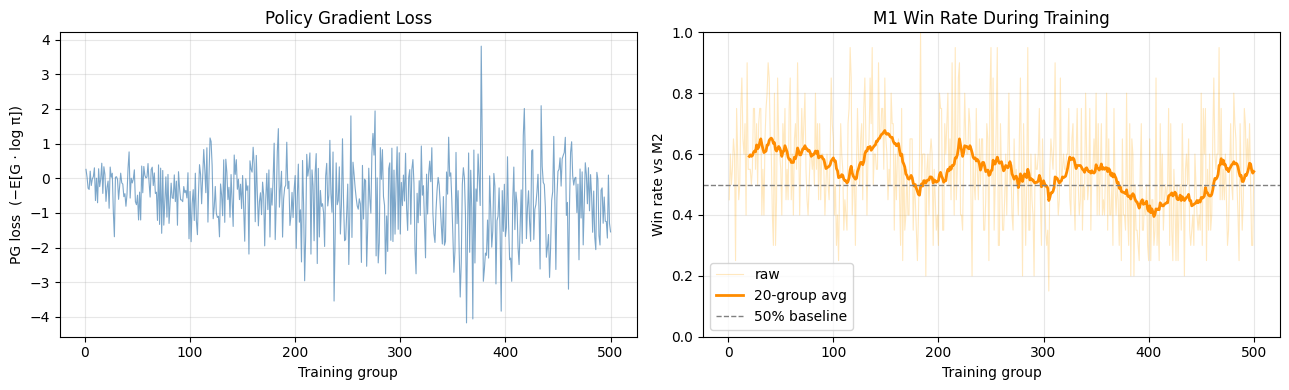

Final 20-group average win rate: 54.2%
Figure saved to C:\Users\stile\Desktop\Opti Proj 3\logs\training_curves.png


In [ ]:
# ── Cell 6: Plot training results ─────────────────────────────────────────────
groups    = np.array(log["group"])
losses    = np.array(log["loss"])
win_rates = np.array(log["win_rate"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss curve
ax1.plot(groups, losses, color="steelblue", linewidth=0.8, alpha=0.7)
ax1.set_xlabel("Training group")
ax1.set_ylabel("PG loss  (−E[G · log π])")
ax1.set_title("Policy Gradient Loss")
ax1.grid(True, alpha=0.3)

# ── Win-rate curve with rolling average
WINDOW = 20
ax2.plot(groups, win_rates, alpha=0.25, color="orange", linewidth=0.8, label="raw")
if len(win_rates) >= WINDOW:
    smoothed = np.convolve(win_rates, np.ones(WINDOW) / WINDOW, mode="valid")
    ax2.plot(groups[WINDOW - 1:], smoothed, color="darkorange",
             linewidth=2, label=f"{WINDOW}-group avg")
ax2.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="50% baseline")
ax2.set_xlabel("Training group")
ax2.set_ylabel("Win rate vs M2")
ax2.set_title("M1 Win Rate During Training")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(str(config.LOG_DIR), "training_curves.png")
plt.savefig(fig_path, dpi=150)
plt.show()

if len(win_rates) >= WINDOW:
    print(f"Final {WINDOW}-group average win rate: {smoothed[-1]:.1%}")
print(f"Figure saved to {fig_path}")